# Análise de Ticket Médio por Região

Análise dos pedidos entregues da Olist, calculando o ticket médio por região brasileira a partir do estado do cliente.

## 1. Objetivo

Identificar o ticket médio dos pedidos por região do Brasil.

**Ticket Médio = Faturamento ÷ Número de Pedidos**

O valor de cada pedido considera **preço + frete**. Pedidos com mais de um item são consolidados antes do cálculo, para que cada `order_id` represente apenas um ticket.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


## 2. Importação das bases

In [2]:
# Os arquivos devem estar na mesma pasta deste notebook

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print('Pedidos:', orders.shape)
print('Itens:', order_items.shape)
print('Clientes:', customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Preparação dos dados

In [3]:
# Mantendo somente pedidos entregues
orders_delivered = orders[
    orders['order_delivered_customer_date'].notna()
][['order_id', 'customer_id']].copy()

print('Pedidos entregues:', orders_delivered['order_id'].nunique())

Pedidos entregues: 96476


In [4]:
# Calculando o valor total de cada item
order_items['item_total'] = (
    order_items['price'] + order_items['freight_value']
)

# Consolidando o valor de todos os itens de cada pedido
order_values = (
    order_items
    .groupby('order_id', as_index=False)['item_total']
    .sum()
    .rename(columns={'item_total': 'order_value'})
)

order_values.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


## 4. Relacionamento entre pedidos e clientes

In [5]:
base = (
    orders_delivered
    .merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
    .merge(
        order_values,
        on='order_id',
        how='left'
    )
)

## 5. Classificação dos estados por região

In [6]:
regiao_map = {
    # Sudeste
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',

    # Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul',

    # Nordeste
    'BA': 'Nordeste', 'SE': 'Nordeste', 'AL': 'Nordeste',
    'PE': 'Nordeste', 'PB': 'Nordeste', 'RN': 'Nordeste',
    'CE': 'Nordeste', 'PI': 'Nordeste', 'MA': 'Nordeste',

    # Centro-Oeste
    'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',

    # Norte
    'AM': 'Norte', 'PA': 'Norte', 'AC': 'Norte',
    'RO': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'TO': 'Norte'
}

# Criando a região diretamente na base já criada anteriormente
base['regiao'] = base['customer_state'].map(regiao_map)

base[['customer_state', 'regiao']].drop_duplicates().sort_values('customer_state')


,customer_state,regiao
746,AC,Norte
604,AL,Nordeste
937,AM,Norte
195,AP,Norte
1,BA,Nordeste
35,CE,Nordeste
41,DF,Centro-Oeste
182,ES,Sudeste
2,GO,Centro-Oeste
373,MA,Nordeste


## 6. Ticket médio por região

Cálculo do número de pedidos, faturamento e ticket médio para cada região.

In [7]:
ticket_regiao = (
    base
    .groupby('regiao', as_index=False)
    .agg(
        pedidos=('order_id', 'nunique'),
        faturamento=('order_value', 'sum')
    )
)

ticket_regiao['ticket_medio'] = (
    ticket_regiao['faturamento'] / ticket_regiao['pedidos']
)

ticket_regiao = (
    ticket_regiao
    .sort_values('ticket_medio', ascending=False)
    .reset_index(drop=True)
)

ticket_regiao


,regiao,pedidos,faturamento,ticket_medio
0,Norte,1796,401339.07,223.46
1,Nordeste,9044,1822543.32,201.52
2,Centro-Oeste,5624,995927.67,177.09
3,Sul,13814,2238268.88,162.03
4,Sudeste,66198,9961064.47,150.47


## 7. Resultado formatado

In [17]:
resultado_ticket = ticket_regiao.copy()

resultado_ticket['faturamento'] = resultado_ticket['faturamento'].map(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

resultado_ticket['ticket_medio'] = resultado_ticket['ticket_medio'].map(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

resultado_ticket.columns = [
    'Região', 'Pedidos', 'Faturamento', 'Ticket Médio'
]

resultado_ticket

,Região,Pedidos,Faturamento,Ticket Médio
0,Norte,1796,"R$ 401.339,07","R$ 223,46"
1,Nordeste,9044,"R$ 1.822.543,32","R$ 201,52"
2,Centro-Oeste,5624,"R$ 995.927,67","R$ 177,09"
3,Sul,13814,"R$ 2.238.268,88","R$ 162,03"
4,Sudeste,66198,"R$ 9.961.064,47","R$ 150,47"


## 8. Gráfico — Ticket Médio por Região

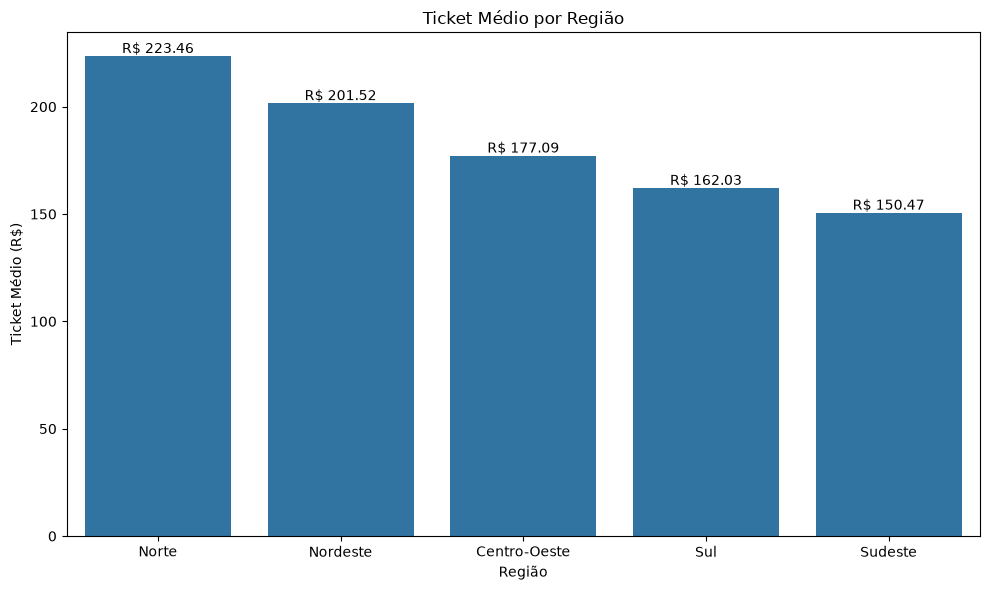

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=ticket_regiao,
    x='regiao',
    y='ticket_medio'
)

plt.title('Ticket Médio por Região')
plt.xlabel('Região')
plt.ylabel('Ticket Médio (R$)')

for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.2f')

plt.tight_layout()
plt.show()


## 9. Ranking das Regiões

Ranking das regiões pelo ticket médio, mantendo também o volume de pedidos e o faturamento.

In [18]:
ranking = (
    ticket_regiao[
        ['regiao', 'pedidos', 'faturamento', 'ticket_medio']
    ]
    .copy()
)

ranking.insert(0, 'Ranking', range(1, len(ranking) + 1))

ranking


,Ranking,regiao,pedidos,faturamento,ticket_medio
0,1,Norte,1796,401339.07,223.46
1,2,Nordeste,9044,1822543.32,201.52
2,3,Centro-Oeste,5624,995927.67,177.09
3,4,Sul,13814,2238268.88,162.03
4,5,Sudeste,66198,9961064.47,150.47


## 10. Ticket Médio x Quantidade de Pedidos

O gráfico permite analisar conjuntamente o valor médio dos pedidos e o volume de vendas de cada região.

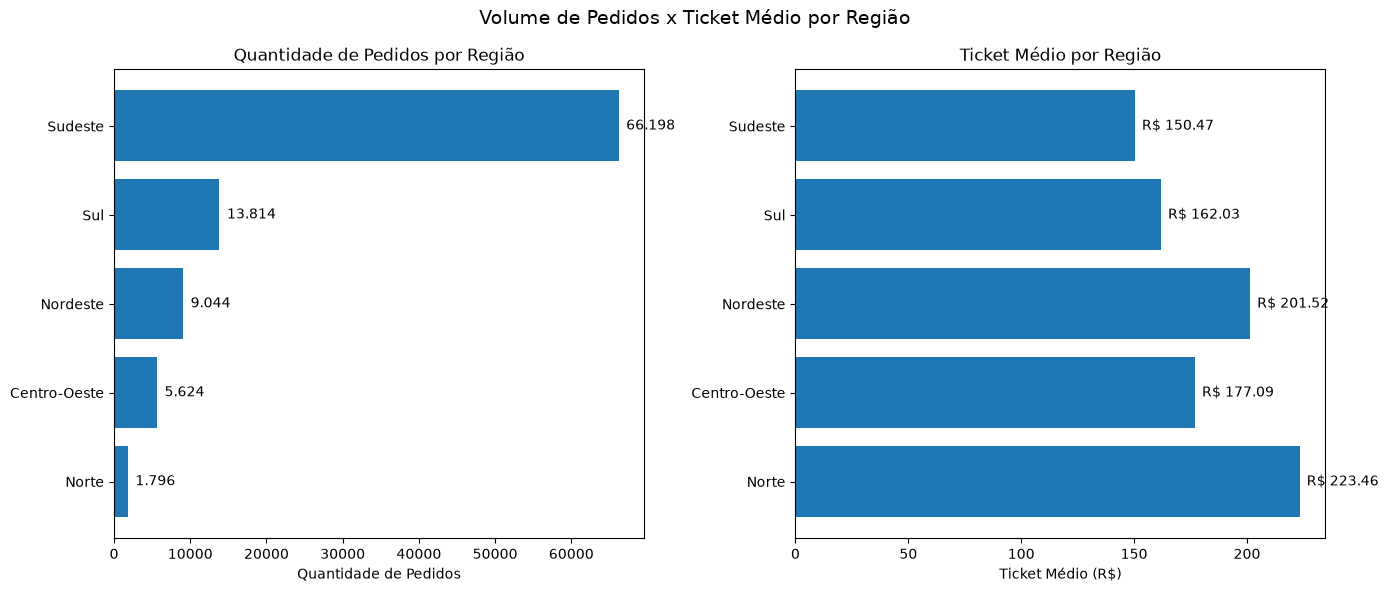

In [13]:
# ============================================
# 10. QUANTIDADE DE PEDIDOS X TICKET MÉDIO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ordenação pela quantidade de pedidos
dados = ranking.sort_values('pedidos', ascending=True)


# --------------------------------------------
# Gráfico 1 - Quantidade de pedidos
# --------------------------------------------

axes[0].barh(
    dados['regiao'],
    dados['pedidos']
)

axes[0].set_title('Quantidade de Pedidos por Região')
axes[0].set_xlabel('Quantidade de Pedidos')
axes[0].set_ylabel('')


# Valores nas barras
for i, valor in enumerate(dados['pedidos']):
    axes[0].text(
        valor + 1000,
        i,
        f'{valor:,.0f}'.replace(',', '.'),
        va='center'
    )


# --------------------------------------------
# Gráfico 2 - Ticket médio
# --------------------------------------------

axes[1].barh(
    dados['regiao'],
    dados['ticket_medio']
)

axes[1].set_title('Ticket Médio por Região')
axes[1].set_xlabel('Ticket Médio (R$)')
axes[1].set_ylabel('')


# Valores nas barras
for i, valor in enumerate(dados['ticket_medio']):
    axes[1].text(
        valor + 3,
        i,
        f'R$ {valor:.2f}',
        va='center'
    )


plt.suptitle(
    'Volume de Pedidos x Ticket Médio por Região',
    fontsize=14
)

plt.tight_layout()
plt.show()

## 11. Insight da análise

A análise evidencia uma relação inversa entre volume de pedidos e ticket médio. O Norte apresenta o maior ticket médio, porém possui o menor volume de pedidos. Já o Sudeste concentra a maior quantidade de pedidos, mas apresenta o menor ticket médio. Esse cenário indica potencial para elevar o valor médio das compras nas regiões de maior volume, especialmente no Sudeste.